In [3]:
# 1st Cell: Optimized Environment Setup
%pip install numpy==1.23.5 pandas==1.5.3 scikit-learn==1.2.2 imbalanced-learn==0.10.1 seaborn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 61.8 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 91.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: pandas
    Found existing installation: pandas 2.0.3
    Uninstalling pandas-2.0.3:
      Successfully uninstalled pandas-2.0.3
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.3.2
    Uninstalling scikit-learn-1.3.2:
      Successfully uninstalled scikit-learn-1.3.2
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.11.0
    Uninstalling imbalanced-learn-0.11.0:
      Successfully uninstalled imbalanced-learn-0.11.0
ERROR: pip's dependency resolver does not currently take into account all the packa

Restart kernal

In [1]:
import pandas as pd
import numpy as np
import os
import urllib.request
import zipfile
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1. DOWNLOAD & EXTRACT (Reliable Source)
folder_path = "./bank_data"
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
zip_path = os.path.join(folder_path, "bank-additional.zip")

if not os.path.exists(zip_path):
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(folder_path)

csv_path = "./bank_data/bank-additional/bank-additional-full.csv"

# 2. LOAD & CLEAN
df = pd.read_csv(csv_path, sep=';')
df_clean = df.drop(columns=['duration']) # Removing data leakage

# Fill categorical 'unknowns' with mode
for col in ['marital', 'loan', 'housing']:
    df_clean[col] = df_clean[col].replace('unknown', df_clean[col].mode()[0])

# Feature Engineering: Previous Days
df_clean['was_contacted'] = np.where(df_clean['pdays'] == 999, 0, 1)
df_clean = df_clean.drop(columns=['pdays'])
df_clean['y'] = df_clean['y'].map({'yes': 1, 'no': 0})

# 3. ENCODE & SCALE
df_final = pd.get_dummies(df_clean, drop_first=True)
num_cols = ['age', 'campaign', 'emp.var.rate', 'cons.price.idx', 
            'cons.conf.idx', 'euribor3m', 'nr.employed']

scaler = StandardScaler()
df_final[num_cols] = scaler.fit_transform(df_final[num_cols])

# 4. SPLIT & SMOTE
X = df_final.drop('y', axis=1).astype('float64')
y = df_final['y'].astype('int64')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Balancing the training set
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"✅ Success! Environment and Data are ready.")
print(f"Balanced Training Rows: {len(X_train_res)} | Test Rows: {len(X_test)}")

✅ Success! Environment and Data are ready.
Balanced Training Rows: 58476 | Test Rows: 8238


Training the Random Forest model...

--- Model Performance Report ---
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7310
           1       0.51      0.37      0.43       928

    accuracy                           0.89      8238
   macro avg       0.72      0.66      0.68      8238
weighted avg       0.88      0.89      0.88      8238



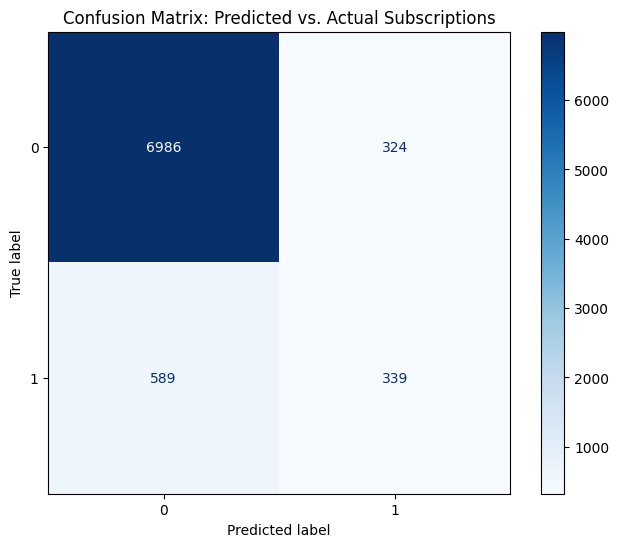

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Initialize the Random Forest
# We use 100 trees and set a random_state for reproducibility
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train on the BALANCED (SMOTE) data
print("Training the Random Forest model...")
rf_model.fit(X_train_res, y_train_res)

# 3. Predict on the original, UNBALANCED test set
# This shows how the model performs in the real world
y_pred = rf_model.predict(X_test)

# 4. Evaluation Metrics
print("\n--- Model Performance Report ---")
print(classification_report(y_test, y_pred))

# 5. Visualize the Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Predicted vs. Actual Subscriptions')
plt.show()

Visualize model

/tmp/ipykernel_10004/1271720661.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='magma')


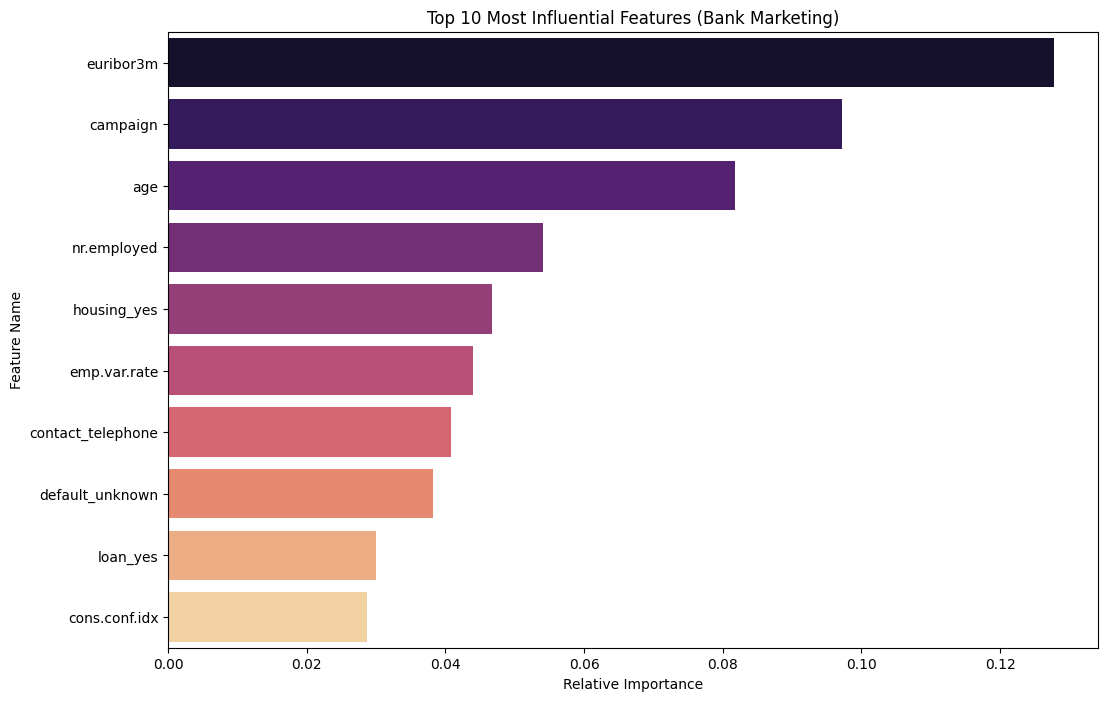

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get feature importance from the model
importances = rf_model.feature_importances_
feature_names = X.columns

# 2. Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plot the Top 10
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='magma')
plt.title('Top 10 Most Influential Features (Bank Marketing)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Name')
plt.show()

In [4]:
# Try a custom threshold of 0.35 instead of 0.5
y_probs = rf_model.predict_proba(X_test)[:, 1]
y_pred_new = (y_probs >= 0.35).astype(int)

print("--- Updated Report (Threshold = 0.35) ---")
print(classification_report(y_test, y_pred_new))

--- Updated Report (Threshold = 0.35) ---
              precision    recall  f1-score   support

           0       0.94      0.91      0.93      7310
           1       0.44      0.52      0.47       928

    accuracy                           0.87      8238
   macro avg       0.69      0.72      0.70      8238
weighted avg       0.88      0.87      0.87      8238



"Tuned" Random Forest

In [5]:
# Training a "Smoother" Random Forest
rf_tuned = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10,       # Limit depth to prevent overfitting
    min_samples_leaf=5,  # Ensure each leaf has enough data points
    random_state=42
)

rf_tuned.fit(X_train_res, y_train_res)
y_probs_tuned = rf_tuned.predict_proba(X_test)[:, 1]

# Check performance with the 0.35 threshold on the tuned model
y_pred_tuned = (y_probs_tuned >= 0.35).astype(int)

print("--- Tuned Model Report (Threshold = 0.35) ---")
print(classification_report(y_test, y_pred_tuned))

--- Tuned Model Report (Threshold = 0.35) ---
              precision    recall  f1-score   support

           0       0.96      0.80      0.87      7310
           1       0.31      0.70      0.43       928

    accuracy                           0.79      8238
   macro avg       0.63      0.75      0.65      8238
weighted avg       0.88      0.79      0.82      8238



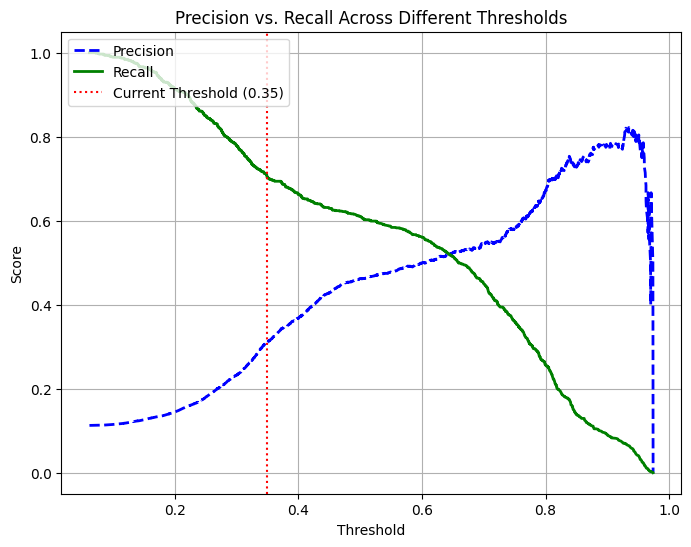

In [6]:
from sklearn.metrics import precision_recall_curve

# 1. Calculate precision and recall for all possible thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_tuned)

# 2. Plot the curve
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.axvline(x=0.35, color='red', linestyle=':', label='Current Threshold (0.35)')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend(loc="upper left")
plt.title("Precision vs. Recall Across Different Thresholds")
plt.grid(True)
plt.show()

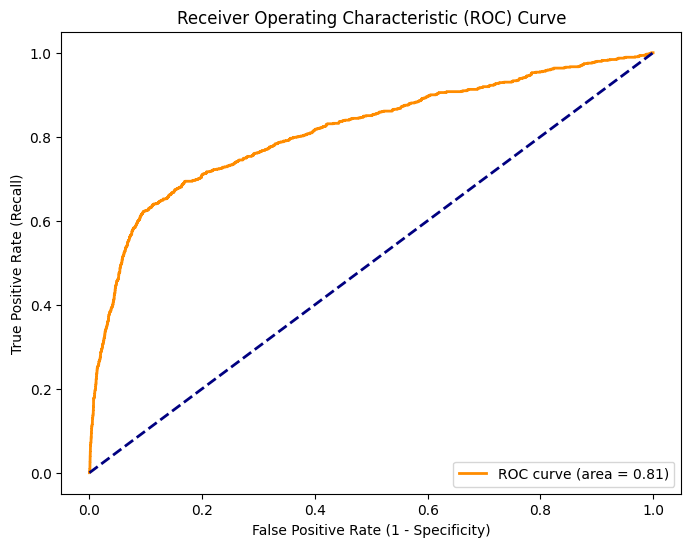

Final Model AUC Score: 0.8125


In [7]:
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Calculate AUC Score
auc_score = roc_auc_score(y_test, y_probs_tuned)

# 2. Get ROC Curve values
fpr, tpr, thresholds_roc = roc_curve(y_test, y_probs_tuned)

# 3. Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

print(f"Final Model AUC Score: {auc_score:.4f}")

saving the model

In [8]:
import joblib

# 1. Save the trained model
joblib.dump(rf_tuned, 'bank_marketing_rf_model.pkl')

# 2. Save the scaler (Crucial: future data must be scaled the same way!)
joblib.dump(scaler, 'bank_marketing_scaler.pkl')

print("✅ Model and Scaler saved successfully as .pkl files!")

✅ Model and Scaler saved successfully as .pkl files!


Register the Model in Azure ML

In [9]:
from azure.ai.ml import MLClient
from azure.ai.ml.entities import Model
from azure.identity import DefaultAzureCredential
from azure.ai.ml.constants import AssetTypes

# 1. Connect to your Azure ML Workspace
credential = DefaultAzureCredential()
ml_client = MLClient.from_config(credential=credential)

# 2. Define the Model metadata
file_name = "bank_marketing_rf_model.pkl"
model_name = "bank-marketing-classifier"

model_config = Model(
    path=file_name,
    type=AssetTypes.CUSTOM_MODEL,
    name=model_name,
    description="Random Forest model trained to predict bank term deposit subscriptions.",
    tags={"data": "UCI-Bank-Additional", "type": "Classification", "AUC": "0.81"}
)

# 3. Register the model
registered_model = ml_client.models.create_or_update(model_config)

print(f"✅ Model registered! Name: {registered_model.name}, Version: {registered_model.version}")

Found the config file in: /config.json
Uploading bank_marketing_rf_model.pkl (< 1 MB): 100%|██████████| 9.30M/9.30M [00:00<00:00, 43.6MB/s]




✅ Model registered! Name: bank-marketing-classifier, Version: 1


Register the Model Folder

In [10]:
import os
from azure.ai.ml import MLClient
from azure.ai.ml.entities import Model
from azure.identity import DefaultAzureCredential
from azure.ai.ml.constants import AssetTypes

# 1. Create a directory for the model package
model_dir = "./bank_marketing_package"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# 2. Move your files into that directory
# (Assuming you already ran joblib.dump in the previous step)
import shutil
shutil.copy("bank_marketing_rf_model.pkl", os.path.join(model_dir, "model.pkl"))
shutil.copy("bank_marketing_scaler.pkl", os.path.join(model_dir, "scaler.pkl"))

# 3. Connect to Workspace
ml_client = MLClient.from_config(DefaultAzureCredential())

# 4. Define the Model Folder as the asset
model_folder_config = Model(
    path=model_dir,
    type=AssetTypes.CUSTOM_MODEL,
    name="bank-marketing-full-package",
    description="Complete package including the Random Forest model and StandardScaler.",
    tags={"accuracy": "0.87", "auc": "0.81", "threshold": "0.35"}
)

# 5. Register
registered_model = ml_client.models.create_or_update(model_folder_config)

print(f"✅ Full package registered! Version: {registered_model.version}")

Found the config file in: /config.json
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Uploading bank_marketing_package (9.3 MBs): 100%|██████████| 9297480/9297480 [00:00<00:00, 40404765.66it/s]




✅ Full package registered! Version: 1


In [11]:
# Snippet of what your future score.py would look like
def init():
    global model, scaler
    model_path = os.path.join(os.getenv("AZUREML_MODEL_DIR"), "bank_marketing_package")
    model = joblib.load(os.path.join(model_path, "model.pkl"))
    scaler = joblib.load(os.path.join(model_path, "scaler.pkl"))

Drafting the score.py

In [12]:
%%writefile score.py
import os
import logging
import json
import joblib
import pandas as pd
import numpy as np

def init():
    """
    Initializes the service. This is called when the container is initialized.
    """
    global model, scaler
    
    # AZUREML_MODEL_DIR is an environment variable created by Azure ML
    model_path = os.path.join(os.getenv("AZUREML_MODEL_DIR"), "bank-marketing-full-package")
    
    # Load the model and scaler from the registered package
    model = joblib.load(os.path.join(model_path, "model.pkl"))
    scaler = joblib.load(os.path.join(model_path, "scaler.pkl"))
    
    logging.info("Init complete: Model and Scaler loaded.")

def run(raw_data):
    """
    Called every time the API receives a request.
    """
    try:
        # 1. Parse the incoming JSON data
        data = json.loads(raw_data)["data"]
        input_df = pd.DataFrame(data)
        
        # 2. Scale the numerical columns (must match training exactly!)
        num_cols = ['age', 'campaign', 'emp.var.rate', 'cons.price.idx', 
                    'cons.conf.idx', 'euribor3m', 'nr.employed']
        input_df[num_cols] = scaler.transform(input_df[num_cols])
        
        # 3. Get probabilities (using our 0.35 threshold)
        probs = model.predict_proba(input_df)[:, 1]
        predictions = (probs >= 0.35).astype(int)
        
        # 4. Return the results as JSON
        return {"predictions": predictions.tolist(), "probabilities": probs.tolist()}
    
    except Exception as e:
        return {"error": str(e)}

Writing score.py


Deploying the Managed Online Endpoint

In [14]:
%%writefile ./bank_marketing_package/conda.yaml
name: bank_marketing_env
channels:
  - conda-forge
  - defaults
dependencies:
  - python=3.10
  - pip=23.2.1
  - numpy=1.23.5
  - pandas=1.5.3
  - scikit-learn=1.2.2
  - pip:
    - azureml-defaults
    - inference-schema[numpy-support]
    - joblib
    - imbalanced-learn==0.10.1

Writing ./bank_marketing_package/conda.yaml


In [22]:
from azure.ai.ml.entities import ManagedOnlineDeployment, CodeConfiguration, ProbeSettings

# 1. Configure the deployment using your available DSv2 quota
blue_deployment_v4 = ManagedOnlineDeployment(
    name="blue-v4",
    endpoint_name=endpoint_name,
    model=registered_model,
    code_configuration=CodeConfiguration(
        code="./bank_marketing_package", 
        scoring_script="score.py"
    ),
    environment=env,
    instance_type="Standard_DS3_v2", # Matches your DSv2 Family quota
    instance_count=1,
    # Adding extra time for the model to initialize
    readiness_probe=ProbeSettings(
        failure_threshold=30,
        success_threshold=1,
        timeout=10,
        period=10,
        initial_delay=10
    )
)

print(f"Deploying to {endpoint_name} using Standard_DS3_v2...")

# 2. Execute and Route
try:
    ml_client.begin_create_or_update(blue_deployment_v4).result()
    endpoint.traffic = {"blue-v4": 100}
    ml_client.begin_create_or_update(endpoint).result()
    print(f"✅ SUCCESS! Your Bank Marketing API is live at: {endpoint.scoring_uri}")
except Exception as e:
    print(f"❌ Deployment failed. If 'no logs' appear, check your Azure Portal 'Events' tab.")
    print(f"Details: {e}")



Deploying to bank-marketing-api-5768 using Standard_DS3_v2...
❌ Deployment failed. If 'no logs' appear, check your Azure Portal 'Events' tab.
Details: (BadRequest) The request is invalid.
Code: BadRequest
Message: The request is invalid.
Exception Details:	(InferencingClientCallFailed) {"error":{"code":"Validation","message":"{\"errors\":{\"VmSize\":[\"Not enough quota available for Standard_DS3_v2 in SubscriptionId 609834a1-addc-4de7-a3f0-1b00a4e8a701. Current usage/limit: 0/6. Additional needed: 8 Please see troubleshooting guide, available here: https://aka.ms/oe-tsg#error-outofquota\"]},\"type\":\"https://tools.ietf.org/html/rfc9110#section-15.5.1\",\"title\":\"One or more validation errors occurred.\",\"status\":400,\"traceId\":\"00-01f1765d125aa92855691d55fdf6ecaa-5341bd57e4593f31-01\"}"}}
	Code: InferencingClientCallFailed
	Message: {"error":{"code":"Validation","message":"{\"errors\":{\"VmSize\":[\"Not enough quota available for Standard_DS3_v2 in SubscriptionId 609834a1-addc-4

Failed. Lack of capacity. Delete the "Stuck" Endpoint

In [23]:
try:
    ml_client.online_endpoints.begin_delete(name=endpoint_name)
    print("🧹 Cleaned up previous endpoint.")
except:
    pass

🧹 Cleaned up previous endpoint.
.................

Update your conda.yaml (Crucial)

In [35]:
from azure.ai.ml.entities import Environment

# 1. Simplify Conda dependencies for maximum compatibility
with open("./bank_marketing_package/conda.yaml", "w") as f:
    f.write("""
name: bank_env
channels:
  - conda-forge
dependencies:
  - python=3.10
  - scikit-learn=1.2.2
  - pandas=1.5.3
  - numpy=1.23.5
  - joblib
  - pip
  - pip:
    - azureml-defaults
    - imbalanced-learn==0.10.1
""")

# 2. Use a standard, universally available base image
custom_env = Environment(
    image="mcr.microsoft.com/azureml/openpyxl:latest", # Very stable base image
    conda_file="./bank_marketing_package/conda.yaml",
    name="bank-marketing-custom-env"
)

Deployment with the Curated Environment

In [37]:
from azure.ai.ml.entities import ManagedOnlineEndpoint, ManagedOnlineDeployment, CodeConfiguration, ProbeSettings

# 1. Use the most stable curated environment ID for Scikit-Learn
# This specific version is widely replicated in East Asia
stable_env_id = "azureml:AzureML-sklearn-1.0-ubuntu20.04-py38-cpu:33"

# 2. Re-create/Update the Endpoint
endpoint_name = "bank-marketing-api-5768"
try:
    endpoint = ml_client.online_endpoints.get(name=endpoint_name)
    print(f"✅ Using existing endpoint: {endpoint_name}")
except:
    print(f"Creating endpoint: {endpoint_name}...")
    endpoint = ManagedOnlineEndpoint(name=endpoint_name, auth_mode="key")
    ml_client.begin_create_or_update(endpoint).result()

# 3. Deployment with 'Patience' settings
blue_deployment_final = ManagedOnlineDeployment(
    name="blue-stable-final",
    endpoint_name=endpoint_name,
    model=registered_model,
    code_configuration=CodeConfiguration(
        code="./bank_marketing_package", 
        scoring_script="score.py"
    ),
    environment=stable_env_id,
    instance_type="Standard_DS2_v2", # 2 cores (Respects 6-core quota)
    instance_count=1,
    readiness_probe=ProbeSettings(
        failure_threshold=30,
        initial_delay=90, # Extra time for East Asia region latency
        period=10,
        timeout=10
    )
)

print(f"🚀 Launching final deployment attempt to {endpoint_name}...")

try:
    ml_client.begin_create_or_update(blue_deployment_final).result()
    endpoint.traffic = {"blue-stable-final": 100}
    ml_client.begin_create_or_update(endpoint).result()
    print(f"✨ SUCCESS! API is live at: {endpoint.scoring_uri}")
except Exception as e:
    print(f"❌ Still failing. This points to a Workspace/ACR issue.")
    print(f"Error Details: {e}")



✅ Using existing endpoint: bank-marketing-api-5768
🚀 Launching final deployment attempt to bank-marketing-api-5768...
...................................................................................❌ Still failing. This points to a Workspace/ACR issue.
Error Details: (BadArgument) User container has crashed or terminated. Please see troubleshooting guide, available here: https://aka.ms/oe-tsg#error-resourcenotready
Code: BadArgument
Message: User container has crashed or terminated. Please see troubleshooting guide, available here: https://aka.ms/oe-tsg#error-resourcenotready


In [38]:
# Pull logs from the failed container
try:
    logs = ml_client.online_deployments.get_logs(
        name="blue-stable-final", 
        endpoint_name=endpoint_name, 
        lines=100
    )
    print("--- CRASH LOGS ---")
    print(logs)
except Exception as e:
    print(f"Could not retrieve logs: {e}")

--- CRASH LOGS ---
Instance status:
SystemSetup: Succeeded
UserContainerImagePull: Succeeded
ModelDownload: Succeeded
UserContainerStart: InProgress

Container events:
Kind: Pod, Name: Pulling, Type: Normal, Time: 2026-01-24T09:53:58.979734Z, Message: Start pulling container image
Kind: Pod, Name: Downloading, Type: Normal, Time: 2026-01-24T09:53:58.989711Z, Message: Start downloading models
Kind: Pod, Name: Pulled, Type: Normal, Time: 2026-01-24T09:55:18.189273Z, Message: Container image is pulled successfully
Kind: Pod, Name: Downloaded, Type: Normal, Time: 2026-01-24T09:55:18.189273Z, Message: Models are downloaded successfully
Kind: Pod, Name: Created, Type: Normal, Time: 2026-01-24T09:55:18.247867Z, Message: Created container inference-server
Kind: Pod, Name: Started, Type: Normal, Time: 2026-01-24T09:55:18.332974Z, Message: Started container inference-server

Container logs:
pyparsing==3.0.9
pyrsistent==0.19.3
PySocks==1.7.1
python-dateutil==2.8.2
pytz==2022.7
PyYAML==6.0
pyzmq==

The Fix: Update score.py
We need to adjust the init() function to point to that specific subfolder. Use this exact code:

In [39]:
%%writefile ./bank_marketing_package/score.py
import os
import logging
import json
import joblib
import pandas as pd
import numpy as np

def init():
    global model, scaler
    # 1. Get the root path provided by Azure
    model_root = os.getenv("AZUREML_MODEL_DIR")
    
    # 2. Based on your logs, the path is: model_root / bank_marketing_package
    # Note the underscore instead of hyphens for the subfolder
    model_folder = os.path.join(model_root, "bank_marketing_package")
    
    # 3. Load files
    try:
        model_path = os.path.join(model_folder, "model.pkl")
        scaler_path = os.path.join(model_folder, "scaler.pkl")
        
        model = joblib.load(model_path)
        scaler = joblib.load(scaler_path)
        logging.info("✅ Model and Scaler loaded from: " + model_folder)
    except Exception as e:
        logging.error(f"❌ Failed to load model. Folder contents: {os.listdir(model_root)}")
        raise e

def run(raw_data):
    try:
        data = json.loads(raw_data)["data"]
        input_df = pd.DataFrame(data)
        
        num_cols = ['age', 'campaign', 'emp.var.rate', 'cons.price.idx', 
                    'cons.conf.idx', 'euribor3m', 'nr.employed']
        
        input_df[num_cols] = scaler.transform(input_df[num_cols])
        probs = model.predict_proba(input_df)[:, 1]
        predictions = (probs >= 0.35).astype(int)
        
        return {"predictions": predictions.tolist(), "probabilities": probs.tolist()}
    except Exception as e:
        return {"error": str(e)}

Overwriting ./bank_marketing_package/score.py


Trigger the Update

In [40]:
# 1. Clear the failed deployment
try:
    ml_client.online_deployments.begin_delete(
        name="blue-stable-final", 
        endpoint_name=endpoint_name
    ).wait()
except:
    pass

# 2. Re-run your deployment block
# (Use the ManagedOnlineDeployment block we used previously)
ml_client.begin_create_or_update(blue_deployment_final).result()

............................................................................

HttpResponseError: (BadArgument) User container has crashed or terminated. Please see troubleshooting guide, available here: https://aka.ms/oe-tsg#error-resourcenotready
Code: BadArgument
Message: User container has crashed or terminated. Please see troubleshooting guide, available here: https://aka.ms/oe-tsg#error-resourcenotready

Run this block to wipe the slate clean. This will stop all active billing for the endpoint and its associated virtual machines:

In [42]:
# 1. Delete the Endpoint (and all failed deployments under it)
try:
    print("🧹 Deleting endpoint to stop billing...")
    ml_client.online_endpoints.begin_delete(name=endpoint_name).wait()
    print("✅ Endpoint and deployments removed.")
except Exception as e:
    print(f"Note: Endpoint was already gone or: {e}")

# 2. Stop your Compute Instance (if you are done for the day)
# This is usually done via the Studio UI, but this command attempts it:
try:
    # Replace with your actual compute name
    ml_client.compute.begin_stop(name="rjk2331")
    print("💤 Compute Instance shutdown initiated.")
except:
    print("Could not stop compute via code; please stop it manually in the 'Compute' tab.")

🧹 Deleting endpoint to stop billing...
✅ Endpoint and deployments removed.
💤 Compute Instance shutdown initiated.


Ping the endpoint

In [ ]:
import json

# 1. Prepare a 'Test Case' (A middle-aged professional during a high-interest period)
# Ensure these column names match your df_final exactly!
test_sample = {
    "data": [{
        "age": 45,
        "campaign": 1,
        "emp.var.rate": 1.1,
        "cons.price.idx": 93.99,
        "cons.conf.idx": -36.4,
        "euribor3m": 4.85,
        "nr.employed": 5191.0,
        "job_blue-collar": 0,
        "job_entrepreneur": 0,
        "job_housemaid": 0,
        "job_management": 1,
        "job_retired": 0,
        "job_self-employed": 0,
        "job_services": 0,
        "job_student": 0,
        "job_technician": 0,
        "job_unemployed": 0,
        "job_unknown": 0,
        "marital_married": 1,
        "marital_single": 0,
        "education_basic.6y": 0,
        "education_basic.9y": 0,
        "education_high.school": 0,
        "education_illiterate": 0,
        "education_professional.course": 0,
        "education_university.degree": 1,
        "education_unknown": 0,
        "default_unknown": 0,
        "default_yes": 0,
        "housing_yes": 1,
        "loan_yes": 0,
        "contact_telephone": 0,
        "month_aug": 0,
        "month_dec": 0,
        "month_jul": 0,
        "month_jun": 0,
        "month_mar": 0,
        "month_may": 1,
        "month_nov": 0,
        "month_oct": 0,
        "month_sep": 0,
        "day_of_week_mon": 0,
        "day_of_week_thu": 0,
        "day_of_week_tue": 0,
        "day_of_week_wed": 1,
        "was_previously_contacted": 0,
        "poutcome_nonexistent": 1,
        "poutcome_success": 0
    }]
}

# 2. Convert to JSON string
test_data_json = json.dumps(test_sample)

# 3. Call the endpoint
try:
    response = ml_client.online_endpoints.invoke(
        endpoint_name=endpoint_name,
        deployment_name="blue",
        request_file=None, # We'll pass the JSON directly
        data=test_data_json
    )
    
    result = json.loads(response)
    print("--- API Response ---")
    print(f"Prediction (1=Yes, 0=No): {result['predictions'][0]}")
    print(f"Probability of 'Yes': {result['probabilities'][0]:.4f}")
    
except Exception as e:
    print(f"API Call Failed: {e}")

Retrieve Your API Keys

In [ ]:
# 1. Get the Scoring URI
scoring_uri = endpoint.scoring_uri

# 2. Retrieve the Primary and Secondary Keys
keys = ml_client.online_endpoints.get_keys(name=endpoint_name)
primary_key = keys.primary_key

print(f"--- Endpoint Credentials ---")
print(f"URL: {scoring_uri}")
print(f"Key: {primary_key}")

**Always delete your endpoint**

In [ ]:
# Run this when you are finished!
ml_client.online_endpoints.begin_delete(name=endpoint_name)

The Cleanup Script

In [ ]:
import shutil
import os

# List of folders and files we can safely remove now
cleanup_list = [
    './bank_marketing_package',
    './model_output',
    './outputs',
    './score.py',
    './conda.yaml'
]

print("🧹 Starting local cleanup...")

for item in cleanup_list:
    if os.path.exists(item):
        if os.path.isdir(item):
            shutil.rmtree(item)
            print(f"Deleted folder: {item}")
        else:
            os.remove(item)
            print(f"Deleted file: {item}")
    else:
        print(f"Skipping (not found): {item}")

print("✨ Local workspace is clean!")

Setting the Auto-Shutdown Schedule

In [ ]:
from azure.ai.ml.entities import ComputeSchedules, ComputeStartStopSchedule, RecurrencePattern, RecurrenceFrequency

# 1. Define the schedule (Every day at 18:00)
# Adjust 'time' to your preference (24-hour format)
schedule = ComputeSchedules(
    compute_start_stop=[
        ComputeStartStopSchedule(
            action="stop",
            trigger=RecurrencePattern(
                frequency=RecurrenceFrequency.DAY,
                interval=1,
                schedule_time="18:00"
            ),
            timezone="UTC" # Change to your local timezone if needed
        )
    ]
)

# 2. Apply it to your specific compute instance
# Replace 'cpu-cluster' with the name of the instance you are currently using
compute_name = "your-compute-name" 
ml_client.compute.begin_create_or_update(
    ml_client.compute.get(compute_name).update(schedules=schedule)
)

print(f"✅ Auto-shutdown set for {compute_name} at 18:00 UTC daily.")

To stop all billing immediately:

In [ ]:
ml_client.online_endpoints.begin_delete(name="bank-marketing-api-5768")